<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/text-analytics-spring-2026/blob/main/Assignment%202/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2: Text Classification

### Marcela Lozano


In [77]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import csv

# Path to your Drive folder
data_path = "/content/drive/MyDrive/"   # change if your folder name is different

fake = pd.read_csv(
    data_path + "Fake.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

real = pd.read_csv(
    data_path + "True.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

fake["label"] = "FAKE"
real["label"] = "REAL"

df = pd.concat([fake, real], ignore_index=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (44898, 5)

Columns: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Data Types:
 title      object
text       object
subject    object
date       object
label      object
dtype: object

Missing Values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",FAKE
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",FAKE
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",FAKE
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",FAKE
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",FAKE


label
FAKE    23481
REAL    21417
Name: count, dtype: int64


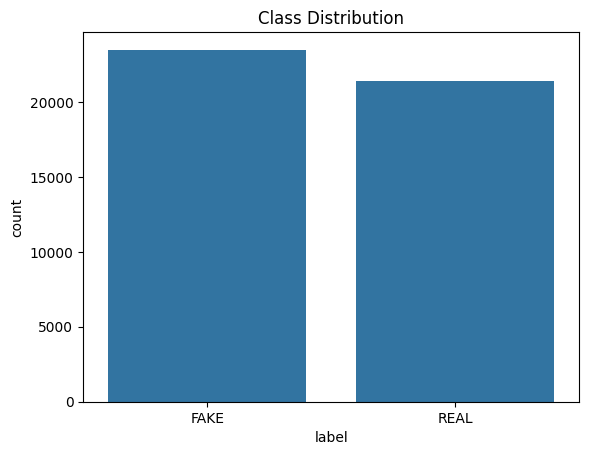

Majority-to-Minority Ratio: 1.0963720409020872


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# class counts
class_counts = df["label"].value_counts()
print(class_counts)

# plot
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

# ratio
ratio = class_counts.max() / class_counts.min()
print("Majority-to-Minority Ratio:", ratio)


In [39]:
# text length
df["text_length"] = df["text"].str.len()

# summary
df.groupby("label")["text_length"].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0
REAL,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0


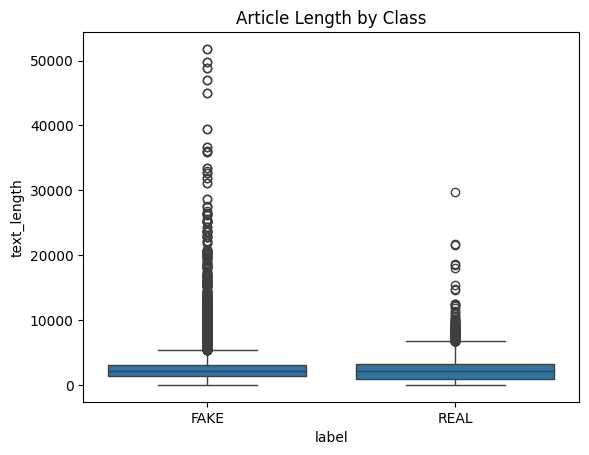

In [40]:
sns.boxplot(data=df, x="label", y="text_length")
plt.title("Article Length by Class")
plt.show()


In [41]:
from collections import Counter
import re

def get_vocab(text_series):
    words = " ".join(text_series).lower()
    words = re.findall(r'\b\w+\b', words)
    return Counter(words)

fake_vocab = get_vocab(df[df["label"]=="FAKE"]["text"])
real_vocab = get_vocab(df[df["label"]=="REAL"]["text"])

print("Fake vocab size:", len(fake_vocab))
print("Real vocab size:", len(real_vocab))


Fake vocab size: 94488
Real vocab size: 66702


In [42]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=20)

fake_words = vectorizer.fit_transform(df[df["label"]=="FAKE"]["text"])
fake_sum = fake_words.sum(axis=0)

fake_freq = [(word, fake_sum[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
fake_freq = sorted(fake_freq, key=lambda x: x[1], reverse=True)

print("Top Fake Words:", fake_freq[:10])


Top Fake Words: [('trump', np.int64(79300)), ('said', np.int64(33763)), ('president', np.int64(27715)), ('people', np.int64(26570)), ('just', np.int64(20511)), ('clinton', np.int64(19173)), ('obama', np.int64(18797)), ('like', np.int64(18097)), ('donald', np.int64(17671)), ('news', np.int64(14620))]


In [43]:
real_words = vectorizer.fit_transform(df[df["label"]=="REAL"]["text"])
real_sum = real_words.sum(axis=0)

real_freq = [(word, real_sum[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
real_freq = sorted(real_freq, key=lambda x: x[1], reverse=True)

print("Top Real Words:", real_freq[:10])


Top Real Words: [('said', np.int64(99062)), ('trump', np.int64(54700)), ('reuters', np.int64(28976)), ('president', np.int64(28177)), ('state', np.int64(21025)), ('government', np.int64(18846)), ('new', np.int64(16917)), ('states', np.int64(16652)), ('house', np.int64(16640)), ('republican', np.int64(16243))]


###Step 3: Text Cleaning and Preprocessing

News/formal text: Standard cleaning, remove punctuation, normalize.


In [44]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [45]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)


In [46]:
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()


,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump wish american happy new year leav...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...


In [47]:
for i in range(2):
    fake_example = df[df["label"] == "FAKE"].iloc[i]
    real_example = df[df["label"] == "REAL"].iloc[i]

    print(f"\n===== FAKE ARTICLE {i+1} BEFORE =====\n")
    print(fake_example["text"][:400])

    print(f"\n===== FAKE ARTICLE {i+1} AFTER =====\n")
    print(fake_example["clean_text"][:400])

    print("\n" + "="*60)

    print(f"\n===== REAL ARTICLE {i+1} BEFORE =====\n")
    print(real_example["text"][:400])

    print(f"\n===== REAL ARTICLE {i+1} AFTER =====\n")
    print(real_example["clean_text"][:400])

    print("\n" + "#"*80)



===== FAKE ARTICLE 1 BEFORE =====

Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishone

===== FAKE ARTICLE 1 AFTER =====

donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweeted 2018 great year america country rapidly grows stronger smarter want wish friend supporter enemy hat


===== REAL ARTICLE 1 BEFORE =====

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress,

##Step 4: Tokenize and feature engineer

In [48]:
X = df["clean_text"]
y = df["label"]


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))


Training size: 35918
Test size: 8980


Feature Engineering Approach 1: TF-IDF

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)


TF-IDF train shape: (35918, 5000)
TF-IDF test shape: (8980, 5000)


TF-IDF is useful because it decreases the weights of very common words and emphasizes the more informative terms. It is typically used for news classification.

Feature Engineering Approach 2: Count Vectorization

In [51]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

print("Count train shape:", X_train_count.shape)
print("Count test shape:", X_test_count.shape)


Count train shape: (35918, 5000)
Count test shape: (8980, 5000)


Feature Engineering Approach 2: Count Vectorization

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label="FAKE")
    rec = recall_score(y_test, y_pred, pos_label="FAKE")
    f1 = f1_score(y_test, y_pred, pos_label="FAKE")

    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }


Model 1: Logistic Regression with TF-IDF

In [53]:
from sklearn.linear_model import LogisticRegression

lr_tfidf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

results = []

results.append(
    evaluate_model(
        lr_tfidf,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test,
        "Logistic Regression + TF-IDF"
    )
)



--- Logistic Regression + TF-IDF ---
Accuracy: 0.9876
Precision: 0.9931
Recall: 0.9832
F1 Score: 0.9881

Classification Report:

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      4696
        REAL       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



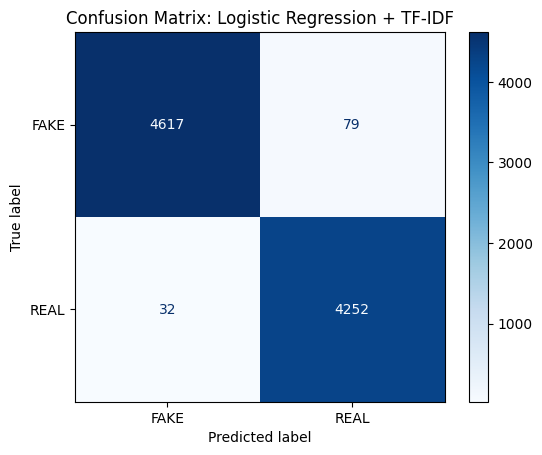

In [54]:
# Predictions for Logistic Regression
y_pred_lr = lr_tfidf.predict(X_test_tfidf)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(cm_lr, display_labels=["FAKE","REAL"]).plot(cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression + TF-IDF")
plt.show()


Model 2: Multinomial Naive Bayes with CountVectorizer

In [55]:
from sklearn.naive_bayes import MultinomialNB

nb_count = MultinomialNB()

results.append(
    evaluate_model(
        nb_count,
        X_train_count,
        X_test_count,
        y_train,
        y_test,
        "Naive Bayes + CountVectorizer"
    )
)



--- Naive Bayes + CountVectorizer ---
Accuracy: 0.957
Precision: 0.9658
Recall: 0.9514
F1 Score: 0.9586

Classification Report:

              precision    recall  f1-score   support

        FAKE       0.97      0.95      0.96      4696
        REAL       0.95      0.96      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



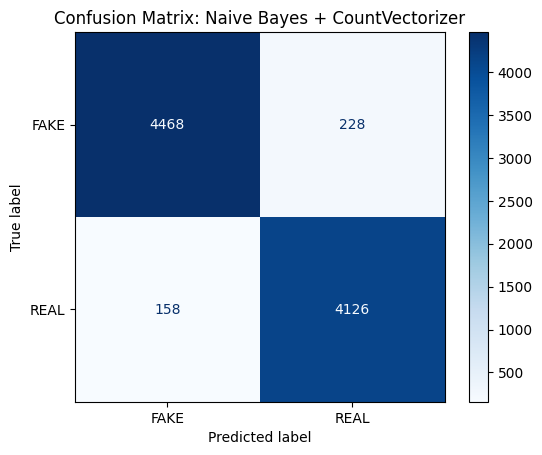

In [56]:
# Predictions for Naive Bayes
y_pred_nb = nb_count.predict(X_test_count)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

ConfusionMatrixDisplay(cm_nb, display_labels=["FAKE", "REAL"]).plot(cmap="Blues")
plt.title("Confusion Matrix: Naive Bayes + CountVectorizer")
plt.show()


Model 3: SVM with TF-IDF

In [57]:
from sklearn.svm import LinearSVC

svm_tfidf = LinearSVC(
    class_weight="balanced",
    random_state=42
)

results.append(
    evaluate_model(
        svm_tfidf,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test,
        "Linear SVM + TF-IDF"
    )
)



--- Linear SVM + TF-IDF ---
Accuracy: 0.9949
Precision: 0.9962
Recall: 0.994
F1 Score: 0.9951

Classification Report:

              precision    recall  f1-score   support

        FAKE       1.00      0.99      1.00      4696
        REAL       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



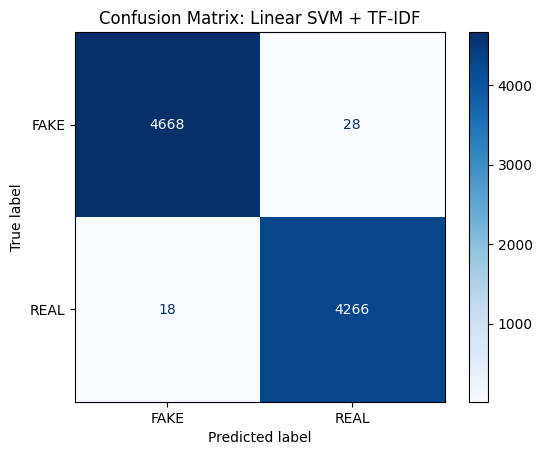

In [58]:
# Predictions for Linear SVM
y_pred_svm = svm_tfidf.predict(X_test_tfidf)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(cm_svm, display_labels=["FAKE", "REAL"]).plot(cmap="Blues")
plt.title("Confusion Matrix: Linear SVM + TF-IDF")
plt.show()


### Model Comparison


In [59]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1
2,Linear SVM + TF-IDF,0.994878,0.996159,0.994037,0.995097
0,Logistic Regression + TF-IDF,0.987639,0.993117,0.983177,0.988122
1,Naive Bayes + CountVectorizer,0.957016,0.965845,0.951448,0.958593


Fake news detection requires a balance of two possible errors. If fake news is missed - false negatives - misinformation may continue to spread. Incorrectly labeling real news as fake - false positives - can damage credibility and reduce trust in the system. Since both types of errors are harmful iti is best to try and find a balance between recall and precision.


The F1 score is used as the primary metric because it captures the balance between precision and recall. Among the tested models, Linear SVM with TF-IDF achieved the highest F1 score (0.995) while also maintaining extremely high precision and recall. This model works best for both detecting fake news and avoiding incorrect classification of real articles.

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV Score: 0.9929142907820138


In [61]:
best_lr = grid.best_estimator_

results.append(
    evaluate_model(
        best_lr,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test,
        "Tuned Logistic Regression + TF-IDF"
    )
)



--- Tuned Logistic Regression + TF-IDF ---
Accuracy: 0.9939
Precision: 0.9953
Recall: 0.993
F1 Score: 0.9941

Classification Report:

              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



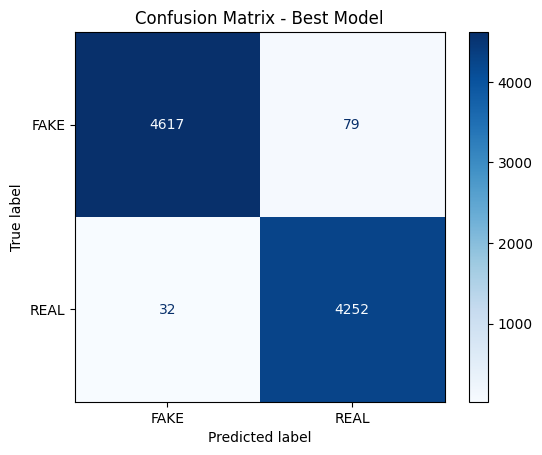

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = lr_tfidf   # replace if another model performs better
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best, labels=["FAKE", "REAL"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.show()


In [63]:
feature_names = tfidf.get_feature_names_out()
coefs = lr_tfidf.coef_[0]

top_fake_idx = coefs.argsort()[-15:]
top_real_idx = coefs.argsort()[:15]

print("Top words predicting FAKE:\n")
for idx in reversed(top_fake_idx):
    print(feature_names[idx], round(coefs[idx], 4))

print("\nTop words predicting REAL:\n")
for idx in top_real_idx:
    print(feature_names[idx], round(coefs[idx], 4))


Top words predicting FAKE:

reuters 24.1438
said 16.2776
washington reuters 9.4982
president donald 5.5209
wednesday 4.7883
washington 4.7677
tuesday 4.5264
thursday 4.1983
reuters president 4.1906
dont 4.1406
friday 4.1041
edt 4.0496
monday 3.8333
im 3.7624
nov 3.6818

Top words predicting REAL:

via -7.9951
image -6.4997
president trump -5.0525
obama -4.9655
gop -4.7746
hillary -4.4952
mr -4.2448
image via -4.1352
even -4.0036
american -3.9502
america -3.718
like -3.6629
rep -3.3713
president obama -3.2012
sen -3.162


In [64]:
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression + TF-IDF",
        "Naive Bayes + CountVectorizer",
        "Linear SVM + TF-IDF"
    ],

    "Accuracy / F1": [
        "Very High (F1 ≈ 0.988)",
        "High (F1 ≈ 0.959)",
        "Highest (F1 ≈ 0.995)"
    ],

    "Speed": [
        "Fast",
        "Very Fast",
        "Fast"
    ],

    "Important Class Performance (FAKE)": [
        "Very strong balance",
        "Good but slightly lower recall",
        "Best balance of precision and recall"
    ],

    "Interpretability": [
        "High (coefficients show word importance)",
        "Medium",
        "Medium–Low"
    ],

    "Ease of Tuning": [
        "Easy",
        "Very Easy",
        "Moderate"
    ]
})

comparison_table


,Model,Accuracy / F1,Speed,Important Class Performance (FAKE),Interpretability,Ease of Tuning
0,Logistic Regression + TF-IDF,Very High (F1 ≈ 0.988),Fast,Very strong balance,High (coefficients show word importance),Easy
1,Naive Bayes + CountVectorizer,High (F1 ≈ 0.959),Very Fast,Good but slightly lower recall,Medium,Very Easy
2,Linear SVM + TF-IDF,Highest (F1 ≈ 0.995),Fast,Best balance of precision and recall,Medium–Low,Moderate


In [69]:


# Create dataframe with predictions
review_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(y_pred_svm).reset_index(drop=True)
})

# Random sample of 20 rows
sample_20 = review_df.sample(20, random_state=42)

# shorten article text so it’s readable
sample_20["text_preview"] = sample_20["text"].str[:200]

# Check if prediction matches
sample_20["agree"] = sample_20["actual"] == sample_20["predicted"]

sample_20[["actual","predicted","agree","text_preview"]]



,actual,predicted,agree,text_preview
5376,FAKE,FAKE,True,november 8 democrat desperately tried dismiss ...
93,FAKE,FAKE,True,sean hannity medium personality able find amaz...
8449,FAKE,FAKE,True,democratic presidential debate thursday night ...
7661,REAL,REAL,True,washington reuters presidentelect donald trump...
994,REAL,REAL,True,corrects paragraph 7 show trump issued warning...
2684,FAKE,FAKE,True,saturday msnbc joy reid repeatedly attempted r...
3148,REAL,REAL,True,milwaukee reuters president barack obama said ...
8748,FAKE,FAKE,True,happier preet bharara attorney brought charge ...
6162,REAL,REAL,True,mogadishu reuters number killed twin bombing s...
7072,FAKE,FAKE,True,remember illegal alien student resident berkel...


In [70]:
print("Correct predictions:", sample_20["agree"].sum(), "/ 20")

Correct predictions: 20 / 20


In [71]:
#Used AI to generate examples
new_texts = [

    # Easy examples (10)
    "Reuters reported that the Senate passed a short term budget bill after bipartisan negotiations in Washington.",
    "The governor announced a new transportation plan to repair highways and expand rail service over the next five years.",
    "Health officials confirmed a rise in seasonal flu cases and encouraged residents to get vaccinated this month.",
    "NASA scientists released new images from the James Webb Space Telescope showing distant galaxies formed billions of years ago.",
    "The Federal Reserve signaled it may raise interest rates again as inflation remains above its target level.",
    "A university research team published a peer reviewed study linking air pollution exposure to increased asthma rates.",
    "An article claimed that a secret underground city has been discovered beneath Antarctica hiding ancient alien technology.",
    "A viral social media post said a homemade mixture of lemon juice and baking soda can permanently cure cancer.",
    "A conspiracy blog reported that world leaders are secretly controlled by a hidden organization of billionaires.",
    "A website claimed thousands of illegal ballots were secretly printed overnight with no official evidence provided.",

    # Tricky examples (5)
    "An opinion columnist joked that artificial intelligence might run for president before Congress finishes regulating it.",
    "A commentary article argued that the government's economic statistics cannot be trusted because they rely on outdated models.",
    "A blog post mixed verified climate data with speculation that scientists exaggerate results to secure research funding.",
    "A commentator suggested that a sudden stock market drop could be linked to coordinated trading by large hedge funds.",
    "An article quoted unnamed sources claiming a major technology merger had already been secretly approved by regulators.",

    # Different context examples (5)
    "A sports journalist reported that a professional soccer player transferred clubs after signing a five year contract.",
    "A technology news website reviewed a new smartphone and highlighted improvements in battery life and camera performance.",
    "A financial newsletter reported that global oil prices increased after supply cuts were announced by exporting countries.",
    "An entertainment magazine wrote that a popular actor will star in a new science fiction film scheduled for release next year.",
    "A health blog claimed that drinking celery juice every morning can detox the body and replace prescription medication."
]
expected_labels = [
    "REAL", "REAL", "REAL", "REAL", "REAL",
    "REAL", "FAKE", "FAKE", "FAKE", "FAKE",
    "FAKE", "FAKE", "FAKE", "FAKE", "FAKE",
    "REAL", "REAL", "REAL", "REAL", "FAKE"
]


In [72]:
new_clean_texts = [clean_text(text) for text in new_texts]

X_new = tfidf.transform(new_clean_texts)

y_new = svm_tfidf.predict(X_new)


In [75]:
example_type = (
    ["Easy"] * 10 +
    ["Tricky"] * 5 +
    ["Different Context"] * 5
)

inference_df = pd.DataFrame({
    "Type": example_type,
    "Text": new_texts,
    "Expected Label": expected_labels,
    "Predicted Label": y_new
})

# Check matches
inference_df["Match"] = inference_df["Expected Label"] == inference_df["Predicted Label"]

# shorten text for readability
inference_df["Text Preview"] = inference_df["Text"].str[:300]

# reorder columns
inference_df = inference_df[
    ["Type", "Expected Label", "Predicted Label", "Match", "Text Preview"]
]

inference_df


,Type,Expected Label,Predicted Label,Match,Text Preview
0,Easy,REAL,REAL,True,Reuters reported that the Senate passed a shor...
1,Easy,REAL,FAKE,False,The governor announced a new transportation pl...
2,Easy,REAL,FAKE,False,Health officials confirmed a rise in seasonal ...
3,Easy,REAL,FAKE,False,NASA scientists released new images from the J...
4,Easy,REAL,FAKE,False,The Federal Reserve signaled it may raise inte...
5,Easy,REAL,FAKE,False,A university research team published a peer re...
6,Easy,FAKE,FAKE,True,An article claimed that a secret underground c...
7,Easy,FAKE,FAKE,True,A viral social media post said a homemade mixt...
8,Easy,FAKE,FAKE,True,A conspiracy blog reported that world leaders ...
9,Easy,FAKE,FAKE,True,A website claimed thousands of illegal ballots...


###Custom Inference Results:
 Out of the 20 custom test samples generated by AI, the model correctly classified 11 out of 20 examples based on manual evaluation.This indicates that while the model performed well on the original dataset, the performance was not as strong when tested on newly generated examples with a range of contexts and wording.

###Performance on Tricky  Examples:
The model performed moderately well on the tricky examples and correctly identified most of them as fake news. Even though these examples contained trickier language, the model was trained on linguisitc patterns often associated with misiniformation so the model was able to correctly flag many of these cases.

###Performance on Out of Domain Examples
The model struggled most with the different context examples. In these examples, the model misclassified legitimate reports as fake news. The training dataset was heavily focused on political news so the vocabulary and structure of articles from other domains were less familiar to the model.

 ###Generalization ability:
 The model performs well within the domain of political news given the high accuracy during testing on the dataset. However, the performance decreases with articles from other subject areas, indicating the models limited ability to generalize.

 ###Production Consideration:
 Based on this sample evaluation, the model could be useful in production if deployed mainly for political news classification. If the goal is to expand classification to a wider range of topics, the model would require additional training data from other news categories. Including a more expansive training dataset would improve the models ability to generalize.